# Internet research 

## Scope

https://www.siglent.eu/product/13555727/siglent-sds814x-hd-4ch-100mhz-12bit-oscilloscope

https://ktln2.org/2018/02/20/control-siglent-oscilloscope/

https://siglentna.com/application-note/programming-example-sds-oscilloscope-screen-capture-python/

## WFG 

https://www.siglent.eu/product/1136898/siglent-sdg1032x-30mhz-function-arbitrary-waveform-generator

https://github.com/tspspi/pysdg1032x

# Pyvisa

https://pyvisa.readthedocs.io/en/latest/

# Logbook 

My google logbook from testing:

[Control software - Google Docs](https://docs.google.com/document/d/1KSsfIMDRvzPyhMPeLPiSNMyzb4p_WQA87ZNAqpBZxXU/edit?tab=t.0)

# Interfacing them

In [85]:
import pyvisa
rm = pyvisa.ResourceManager()
import numpy as np

In [86]:
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'ASRL3::INSTR',
 'ASRL4::INSTR',
 'USB0::0xF4EC::0x1103::SDG1XDDQ802940::INSTR',
 'USB0::0xF4EC::0x1201::SDM35HBQ802212::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808362::INSTR')

In [87]:
rm.list_opened_resources()

[<'USBInstrument'('USB0::0xF4EC::0x1017::SDS08A0Q808362::0::INSTR')>,
 <'USBInstrument'('USB0::0xF4EC::0x1103::SDG1XDDQ802940::0::INSTR')>,
 <'USBInstrument'('USB0::0xF4EC::0x1201::SDM35HBQ802212::0::INSTR')>]

In [28]:
rm.visalib

<IVIVisaLibrary('/Library/Frameworks/visa.framework/visa')>

In [29]:
def get_instrument(rm, keyword):
    instrument = None
    resource_list = rm.list_resources()
    for r in resource_list:
        if keyword in r:
            instrument = rm.open_resource(r)
            break
    return instrument

In [30]:
scope = get_instrument(rm, "SDS")
scope.query("*IDN?")

'Siglent Technologies,SDS814X HD,SDS08A0Q808362,3.8.12.1.1.3.8\n'

In [31]:
wfgen = get_instrument(rm, "SDG")
wfgen.query("*IDN?")

'Siglent Technologies,SDG1032X,SDG1XDDQ802940,1.01.01.33R8\n'

In [32]:
dmm = get_instrument(rm, "SDM")
dmm.query("*IDN?")

'Siglent Technologies,SDM3055,SDM35HBQ802212,1.02.01.28\n'

Awesome, working!

# Grabbing stuff from the scope

### A screenshot 

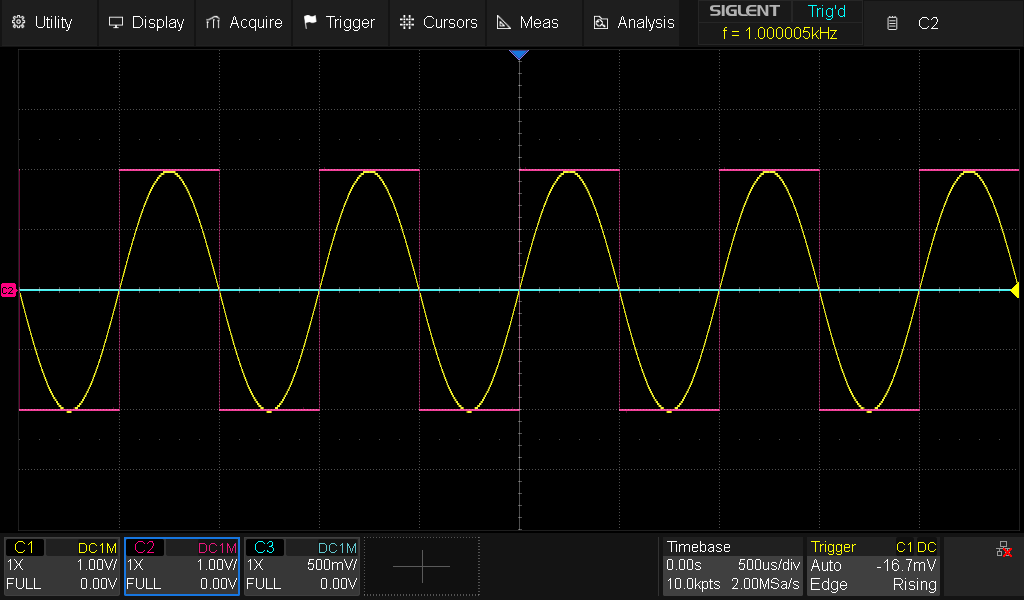

In [33]:
from IPython.display import Image
scope.write("PRIN? PNG")
data = scope.read_raw()
Image(data)

### Grabbing a trace

Let's try to parse the premble:

In [9]:
import time
import struct

# These are two parameters from the manual. But it says:
# "(Modify the following global variables according to the model)."
# I have no idea what the hell HORI_NUM is for the 814x 
# or if I have to change the tdiv_enum
# I guess I can reverse engineer it. 

HORI_NUM = 10
tdiv_enum = [200e-12,500e-12, 1e-9,\
 2e-9, 5e-9, 10e-9, 20e-9, 50e-9, 100e-9, 200e-9, 500e-9, \
 1e-6, 2e-6, 5e-6, 10e-6, 20e-6, 50e-6, 100e-6, 200e-6, 500e-6, \
 1e-3, 2e-3, 5e-3, 10e-3, 20e-3, 50e-3, 100e-3, 200e-3, 500e-3, \
 1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
             
# Start by copy-pasting this from the manual
def parse_preamble(pre):
    WAVE_ARRAY_1 = pre[0x3c:0x3f + 1]
    wave_array_count = pre[0x74:0x77 + 1]
    first_point = pre[0x84:0x87 + 1]
    sp = pre[0x88:0x8b + 1]
    v_scale = pre[0x9c:0x9f + 1]
    v_offset = pre[0xa0:0xa3 + 1]
    interval = pre[0xb0:0xb3 + 1]
    code_per_div = pre[0xa4:0Xa7 + 1]
    adc_bit = pre[0xac:0Xad + 1]
    delay = pre[0xb4:0xbb + 1]
    tdiv = pre[0x144:0x145 + 1]
    probe = pre[0x148:0x14b + 1]

    ta_bytes = struct.unpack('i', WAVE_ARRAY_1)[0]
    point_num = struct.unpack('i', wave_array_count)[0]
    fp = struct.unpack('i', first_point)[0]
    sp = struct.unpack('i', sp)[0]
    interval = struct.unpack('f', interval)[0]
    delay = struct.unpack('d', delay)[0]
    tdiv_index = struct.unpack('h', tdiv)[0]
    probe = struct.unpack('f', probe)[0]
    vdiv = struct.unpack('f', v_scale)[0] * probe
    offset = struct.unpack('f', v_offset)[0] * probe
    code = struct.unpack('f', code_per_div)[0]
    adc_bit = struct.unpack('h', adc_bit)[0]
    tdiv = tdiv_enum[tdiv_index]
    for f in "vdiv, offset, interval, delay, tdiv, code, adc_bit".split(", "):
        print(f, "  ", "\t", eval(f))

In [10]:
scope.write("WAV:SOUR C1")
scope.write("WAV:PRE?")
pre = scope.read_raw()
print(pre)
parse_preamble(pre)

b'#9000000346WAVEDESC\x00\x00\x00\x00\x00\x00\x00\x00WAVEACE\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00Z\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xd0\x07\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00Siglent SDS\x00\x00\x00\x00\x00\xab\xcd\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xd0\x07\x00\x00\xd0\x07\x00\x00\xce\x07\x00\x00\x00\x00\x00\x00\xcf\x07\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\xff\xff\xff\xff\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\xcd\xcc\xcc=\xcd\xcc\xcc\xbe\x00\x00\xf0E\x00\x00\x00\x00\x10\x00\xff\xff_p\x890\x89\xa1\xd2\x11\x8b\xdb\xa2>\x89\xa1\xd2\x11\x8b\xdb\xa2>V\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00S\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [11]:
# The max trace length is 20 million points for the 814x, but the maximum transfer length is 5 million points.
# For traces longer than 5 million points, we need to do 
trace_points = int(float(scope.query(":ACQuire:POINts?")))
max_points_per_transfer = int(float(scope.query("WAV:MAXP?")))
n_transfers = int(np.ceil(trace_points / max_points_per_transfer))

In [12]:
# The 814x has a 16 bit ADC
scope.write("WAV:WIDT WORD")

15

In [13]:
n_reads

NameError: name 'n_reads' is not defined

In [14]:
pre

b'#9000000346WAVEDESC\x00\x00\x00\x00\x00\x00\x00\x00WAVEACE\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00Z\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xd0\x07\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00Siglent SDS\x00\x00\x00\x00\x00\xab\xcd\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xd0\x07\x00\x00\xd0\x07\x00\x00\xce\x07\x00\x00\x00\x00\x00\x00\xcf\x07\x00\x00\x00\x00\x00\x00\x01\x00\x00\x00\xff\xff\xff\xff\x00\x00\x00\x00\x01\x00\x00\x00\x00\x00\x00\x00\xcd\xcc\xcc=\xcd\xcc\xcc\xbe\x00\x00\xf0E\x00\x00\x00\x00\x10\x00\xff\xff_p\x890\x89\xa1\xd2\x11\x8b\xdb\xa2>\x89\xa1\xd2\x11\x8b\xdb\xa2>V\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00S\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [15]:
float(scope.query(":ACQuire:POINts?"))/1e6

0.002

In [16]:
float(scope.query("WAV:MAXP?"))/1e6

5.0

In [17]:
scope.write("WAV:WIDT WORD")

15

In [18]:
help(scope.read_raw)

Help on method read_raw in module pyvisa.resources.messagebased:

read_raw(size: Optional[int] = None) -> bytes method of pyvisa.resources.usb.USBInstrument instance
    Read the unmodified string sent from the instrument to the computer.

    In contrast to read(), no termination characters are stripped.

    Parameters
    ----------
    size : Optional[int], optional
        The chunk size to use to perform the reading. Defaults to None,
        meaning the resource wide set value is set.

    Returns
    -------
    bytes
        Bytes read from the instrument.



## WFM Generator


https://siglentna.com/operating-tip/sdg-remote-scpi-command-to-request-a-screen-image/?pdf=23988

Not in programming manual...

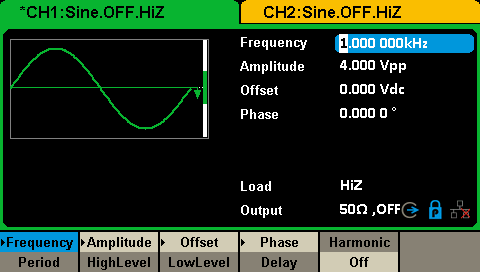

In [19]:
from IPython.display import Image
wfgen.write("SCDP")
data = wfgen.read_raw()
Image(data)

Cool!

# Try making a class

In [36]:
class mydriver(pyvisa.Resource):
    pass

This should now just be a clone of the pyvisa resource class. Wait, I see already the complications. It is probably better to just replicate the read/write/query functions in my class instead of trying to inherit them. 

In [41]:
import datetime
now=datetime.datetime.now()
now.strftime("scope_screenshot_%Y-%m-%d-%H.%M.%S.png")

'scope_screenshot_2025-09-16-14.29.16.png'

In [84]:
import pyvisa
from IPython.display import Image, display
import datetime
import math

class Geneartor:
    def __init__(self, visa_resource):
        self.dev = visa_resource

    def query(self, query_string):
        return self.dev.query(query_string)
    def read(self):
        return self.dev.read()
    def read_raw(self):
        return self.dev.read_raw()
    def write(self, message):
        self.dev.write(message)

    def check_channel(ch):
        if ch != 1 or ch != 2:
            print("Invlid channel:", ch)
        else:
            return True
            
    def set_frequency(self, ch, freq):
        if check_channel(ch):
            self.dev.write("C%d:BSWV FRQ,%.3f" % (ch, freq))

    def set_amplitudte(self, ch, amp):
        if check_channel(ch):
            self.dev.write("C%d:BSWV AMP,%.3f" % (ch, amp))

    def set_offset(self, ch, offset):
        if check_channel(ch):
            self.dev.write("C%d:BSWV OFST,%.3f" % (ch, offset))

    def get_screenshot(self, save_file = True):
        self.dev.write("SCDP")
        data = self.dev.read_raw()
        if save_file:
            timestamp = datetime.datetime.now()
            filename = timestamp.strftime("generator_screenshot_%Y-%m-%d-%H.%M.%S.png")
            with open(filename, "wb") as f:
                f.write(data)        
        display(Image(data))
        
class Scope:
    def __init__(self, visa_resource):
        self.dev = visa_resource
        # needed for reading traces
        self.dev.timeout = 2000 # default value is 2000(2s)
        self.dev.chunk_size = 20 * 1024 * 1024 # default value is 20*1024(20k bytes)

    def query(self, query_string):
        return self.dev.query(query_string)
    def read(self):
        return self.dev.read()
    def read_raw(self):
        return self.dev.read_raw()
    def write(self, message):
        self.dev.write(message)

    def screenshot(self, save_file=True):
        scope.write("PRIN? PNG")
        data = scope.read_raw()
        if save_file:
            timestamp = datetime.datetime.now()
            filename = timestamp.strftime("scope_screenshot_%Y-%m-%d-%H.%M.%S.png")
            with open(filename, "wb") as f:
                f.write(data)
        display(Image(data))

    def get_trace(self, channel_number, npoints = 10000, save_file=True):
        # This is largerly copy-pasted from the manual
        sds = self.dev
        
        HORI_NUM = 10 # for our scope
        tdiv_enum = [200e-12,500e-12, 1e-9,\
         2e-9, 5e-9, 10e-9, 20e-9, 50e-9, 100e-9, 200e-9, 500e-9, \
         1e-6, 2e-6, 5e-6, 10e-6, 20e-6, 50e-6, 100e-6, 200e-6, 500e-6, \
         1e-3, 2e-3, 5e-3, 10e-3, 20e-3, 50e-3, 100e-3, 200e-3, 500e-3, \
         1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
        
        def parse_preamble(recv):
            WAVE_ARRAY_1 = recv[0x3c:0x3f + 1]
            wave_array_count = recv[0x74:0x77 + 1]
            first_point = recv[0x84:0x87 + 1]
            sp = recv[0x88:0x8b + 1]
            v_scale = recv[0x9c:0x9f + 1]
            v_offset = recv[0xa0:0xa3 + 1]
            interval = recv[0xb0:0xb3 + 1]
            code_per_div = recv[0xa4:0Xa7 + 1]
            adc_bit = recv[0xac:0Xad + 1]
            delay = recv[0xb4:0xbb + 1]
            tdiv = recv[0x144:0x145 + 1]
            probe = recv[0x148:0x14b + 1]
            data_bytes = struct.unpack('i', WAVE_ARRAY_1)[0]
            point_num = struct.unpack('i', wave_array_count)[0]
            fp = struct.unpack('i', first_point)[0]
            sp = struct.unpack('i', sp)[0]
            interval = struct.unpack('f', interval)[0]
            delay = struct.unpack('d', delay)[0]
            tdiv_index = struct.unpack('h', tdiv)[0]
            probe = struct.unpack('f', probe)[0]
            vdiv = struct.unpack('f', v_scale)[0] * probe
            offset = struct.unpack('f', v_offset)[0] * probe
            code = struct.unpack('f', code_per_div)[0]
            adc_bit = struct.unpack('h', adc_bit)[0]
            tdiv = tdiv_enum[tdiv_index]
            return vdiv, offset, interval, delay, tdiv, code, adc_bit
               
        # Get the channel waveform parameter data blocks and parse them
        if channel_number > 0 and channel_number < 5:
            # First check if channel is on: if not, then just return
            if "OFF" in sds.query("CHAN%d:SWIT?" % channel_number):
                print("Warning: Channel %d is currently off, please turn it on first" % channel_number)
                return
            else:
                sds.write("WAV:SOUR C%d" % channel_number)
        else:
            print("Channel number must be a number from 1 to 4")
            return
        # Get the preamble
        sds.write("WAV:PREamble?")
        recv_all = sds.read_raw()
        # Find the starting byte 
        recv = recv_all[recv_all.find(b'#') + 11:]
        # Parse the preamble
        vdiv, ofst, interval, trdl, tdiv, vcode_per, adc_bit = parse_preamble(recv)
        # Set the starting datapoint for the transfer
        sds.write(":WAVeform:STARt 0")
        # Get the waveform points and confirm the number of waveform slice reads
        points_in_trace = float(sds.query(":ACQuire:POINts?").strip())
        if not npoints:
            points = points_in_trace
        else:
            if npoints > points_in_trace:
                print("Warning: trace contains only %e points while %e requested" 
                      % (points_in_trace, npoints))
                points = points_in_trace
            else:
                points = npoints
        one_piece_num = float(sds.query(":WAVeform:MAXPoint?").strip())
        read_times = math.ceil(points / one_piece_num)
        # Set the number of read points per slice, if the waveform points is greater than the maximum
        # number of slice reads
        if points > one_piece_num:
            sds.write(":WAVeform:POINt {}".format(one_piece_num))
            # Choose the format of the data returned
            sds.write(":WAVeform:WIDTh BYTE")
        if adc_bit > 8:
            sds.write(":WAVeform:WIDTh WORD")
        #Get the waveform data for each slice
        recv_byte = b'' # initiate variable as a binary string
        for i in range(0, read_times):
            start = i * one_piece_num
            #Set the starting point of each slice
            sds.write(":WAVeform:STARt {}".format(start))
            #Get the waveform data of each slice
            t0 = time.time()
            sds.write("WAV:DATA?")
            recv_rtn = sds.read_raw()
            # print("read time block %d bytes_read %d time %.2f seconds" % (i, len(recv_rtn), (time.time()-t0)))
            # We need to get rid of the two "\n\n" at the end of the received bytes
            # However, we should not use rstrip since it's behavior is not so well defined for 
            # binary streams. But fortunately, there are always two, so we can just get rid of them
            # using slicing. 
            #recv_rtn = recv_rtn.rstrip()
            recv_rtn = recv_rtn[:-2]
            #Splice each waveform data based on data block information
            block_start = recv_rtn.find(b'#')
            data_digit = int(recv_rtn[block_start + 1:block_start + 2])
            data_start = block_start + 2 + data_digit
            bytes_received = len(recv_rtn[data_start:])
            bytes_expected =  (points % one_piece_num) * 2 # hack, the SDS814x is always 16 bit
            if bytes_received < bytes_expected:
                print("Warning: possible short read on data tranfer block", i)
                print("Bytes expected %d, Bytes received %d" % (bytes_expected, bytes_received))
            recv_byte += recv_rtn[data_start:]
        # Unpack signed byte data.
        if adc_bit > 8:
            #print("points", points)
            #print("len(recv_byte)", len(recv_byte))
            convert_data = struct.unpack("=%dh"%points, recv_byte)
        else:
            convert_data = struct.unpack("%db"%points, recv_byte)
        convert_data = np.array(convert_data)
        #Calculate the voltage value and time value
        time_value = []
        volt_value = []
        N = len(convert_data)
        i = np.linspace(0, N-1, N)
        volt_value = convert_data / vcode_per * float(vdiv) -float(ofst)
        time_data = float(tdiv)*HORI_NUM/2 + i*interval + float(trdl)
        
        # The scope fails to transfer data if we ask for data too quickly :(
        # Trail and error suggests we need a 50 ms waiting time here
        # Kindof crappy, but alright considering that any read always
        # takes 200 ms. 
        time.sleep(0.05) 

        if save_file:
            timestamp = datetime.datetime.now()
            filename = timestamp.strftime("scope_trace_%Y-%m-%d-%H.%M.%S.dat")
            np.savetxt(filename, np.array([time_data,volt_value]).T)
            
        return time_data, volt_value
        

In [75]:
scope

<'USBInstrument'('USB0::0xF4EC::0x1017::SDS08A0Q808362::0::INSTR')>

In [76]:
test = Scope(scope)

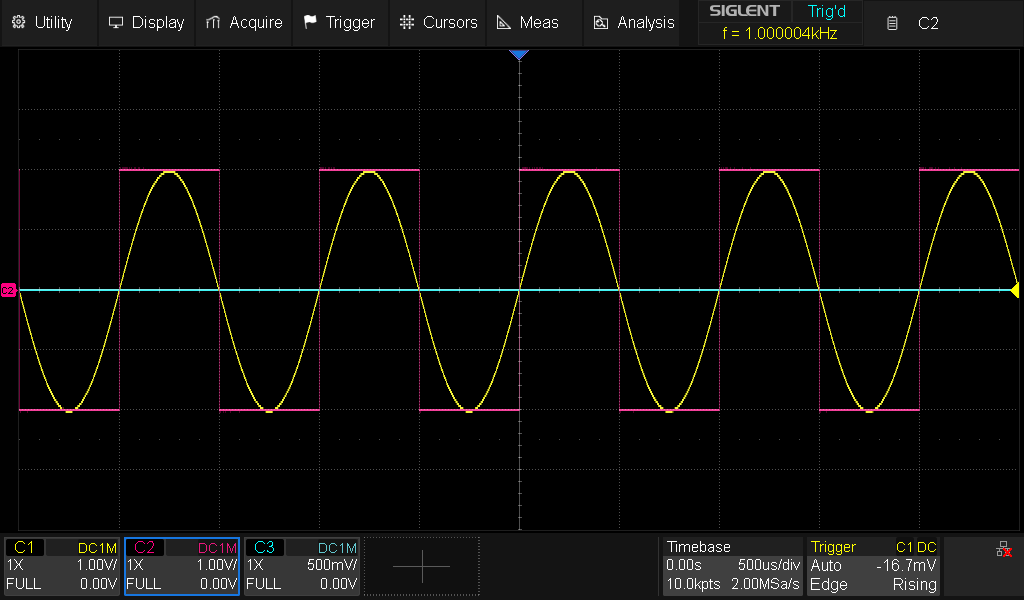

In [77]:
test.screenshot()

In [80]:
t,v = test.get_trace(1)

In [82]:
import matplotlib.pyplot as plt

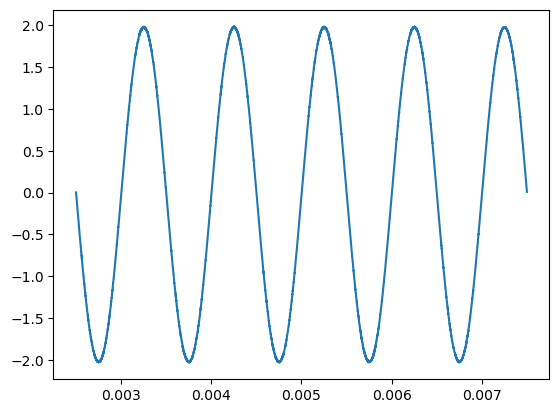

In [83]:
plt.plot(t,v)